# 机器学习基础术语
我们用水果来比喻机器学习的基本概念：
- **数据** : 各种水果的图片和信息
- **特征** : 水果的颜色、大小、形状等属性
- **标签** : 水果的种类（苹果、香蕉、橙子等）
- **模型** : 学到的 识别水果的规则
- **训练** : 认识不同水果的过程
- **预测** : 根据特征判断水果的种类
- **评估** : 检查模型识别水果的准确性
- **推理** : 模型应用于新水果的识别
---

## 数据(Data)

### 数据的类型
#### 1. 结构化数据
- 特点 : 有明确的格式和组织方式 , 想表格一样整齐

In [1]:
import pandas as pd
students_data = {
    '姓名': ['张三', '李四', '王五'],
    '年龄': [18, 19, 20],
    '成绩': [85, 92, 78],
    '班级': ['一班', '二班', '一班']
}
df = pd.DataFrame(students_data)
print(df)

   姓名  年龄  成绩  班级
0  张三  18  85  一班
1  李四  19  92  二班
2  王五  20  78  一班


#### 2. 非结构化数据
- 特点 : 没有固定的格式 , 比如文本、图片、音频等 , 需要特殊处理才能使用

In [2]:
# 非结构化数据示例：文本和图像
text_data = "这个产品质量很好，我很满意！"
# image_data = 一张产品的照片
# audio_data = 顾客的语音评价

### 数据质量的重要性
垃圾进，垃圾出（Garbage In, Garbage Out）是机器学习的重要原则。数据质量直接决定模型效果。

In [3]:
# 数据质量问题示例
import numpy as np
import pandas as pd
# 创建包含各种问题的数据
problematic_data = {
    '价格': [100, 200, None, 300, -50],  # 缺失值和异常值
    '评分': [4.5, '好', 3.8, 4.2, 5.0],  # 数据类型不一致
    '销量': [1000, 1200, 800, 1500, '很多']  # 文本和数字混合
}
df = pd.DataFrame(problematic_data)
print("有问题的数据：")
print(df)
print("\n数据问题分析：")
print(f"缺失值数量：{df.isnull().sum().sum()}")
print(f"数据类型：\n{df.dtypes}")

有问题的数据：
      价格   评分    销量
0  100.0  4.5  1000
1  200.0    好  1200
2    NaN  3.8   800
3  300.0  4.2  1500
4  -50.0  5.0    很多

数据问题分析：
缺失值数量：1
数据类型：
价格    float64
评分     object
销量     object
dtype: object


----

## 特征(Feature)
特征是数据的"可观察属性"，就像描述一个人的特征：身高、体重、发色、性格等。在机器学习中，特征是用来做预测的依据。
特征选择的重要性：
- 好的特征可以显著提高模型的性能
- 不相关或冗余的特征可能会降低模型的效果
- 特征工程往往是机器学习中决定模型效果的关键步骤

### 特征的类型
#### 1. 数值特征
- 代表连续的数值，如身高、体重、价格等。
#### 2. 分类特征
- 代表离散的类别，如性别、职业、颜色等。
#### 3. 文本特征
- 代表文本数据，如评论、文章、对话等。

In [4]:
# 特征工程示例：从原始数据创建有用特征
import pandas as pd
import numpy as np
# 原始数据：房屋信息
house_data = {
    '面积': [80, 120, 60, 150, 90],
    '卧室数': [2, 3, 1, 4, 2],
    '建造年份': [2000, 2010, 1995, 2015, 2005],
    '价格': [200, 350, 150, 500, 280]
}
df = pd.DataFrame(house_data)
# 创建新特征
df['房龄'] = 2023 - df['建造年份']  # 房屋年龄
df['每平米价格'] = df['价格'] / df['面积']  # 单价
df['卧室面积比'] = df['卧室数'] / df['面积'] * 100  # 卧室占比
print("原始数据 + 新特征：")
print(df)
# 特征重要性分析
correlation = df.corr()['价格'].sort_values(ascending=False)
print("\n特征与价格的相关性：")
print(correlation)

原始数据 + 新特征：
    面积  卧室数  建造年份   价格  房龄     每平米价格     卧室面积比
0   80    2  2000  200  23  2.500000  2.500000
1  120    3  2010  350  13  2.916667  2.500000
2   60    1  1995  150  28  2.500000  1.666667
3  150    4  2015  500   8  3.333333  2.666667
4   90    2  2005  280  18  3.111111  2.222222

特征与价格的相关性：
价格       1.000000
面积       0.989375
建造年份     0.979408
卧室数      0.971509
每平米价格    0.898758
卧室面积比    0.740329
房龄      -0.979408
Name: 价格, dtype: float64


----

## 标签(Label)
标签是我们想要预测的"答案"，就像考试题的正确答案一样。在监督学习中，每个数据样本都有一个对应的标签。

### 标签的作用：

- 指导模型学习方向
- 评估模型学习效果
- 定义问题的类型

### 标签的类型
#### 1. 分类标签
- 特点 : 离散的类别值

In [5]:
# 分类标签示例
classification_labels = {
    '邮件类型': ['垃圾邮件', '正常邮件', '垃圾邮件', '正常邮件'],
    '情感倾向': ['正面', '负面', '中性', '正面'],
    '疾病诊断': ['患病', '健康', '健康', '患病']
}

#### 2. 回归标签
- 特点 : 连续的数值值

In [6]:
# 回归标签示例
regression_labels = {
    '房价': [250000, 320000, 180000, 450000],
    '温度': [25.5, 28.3, 22.1, 30.0],
    '股票价格': [100.5, 105.2, 98.7, 110.3]
}

### 标签质量的重要性

In [7]:
# 标签质量问题示例
import numpy as np
# 模拟图像分类任务中的标签问题
image_data = ['cat1.jpg', 'dog1.jpg', 'cat2.jpg', 'dog2.jpg']
problematic_labels = ['猫', '犬', '猫咪', '狗']  # 标签不一致
# 标签标准化
label_mapping = {
    '猫': 'cat', '猫咪': 'cat',
    '犬': 'dog', '狗': 'dog'
}
standardized_labels = [label_mapping[label] for label in problematic_labels]
print("原始标签：", problematic_labels)
print("标准化标签：", standardized_labels)

原始标签： ['猫', '犬', '猫咪', '狗']
标准化标签： ['cat', 'dog', 'cat', 'dog']


----

## 模型(Model)
模型是机器学习算法从数据中学到的"规律"或"模式"，就像学生从课本中学到的知识一样。
模型的本质：

- 数学函数：输入特征，输出预测
- 参数集合：学到的规律的具体表示
- 决策规则：如何从输入得到输出

### 模型的表示

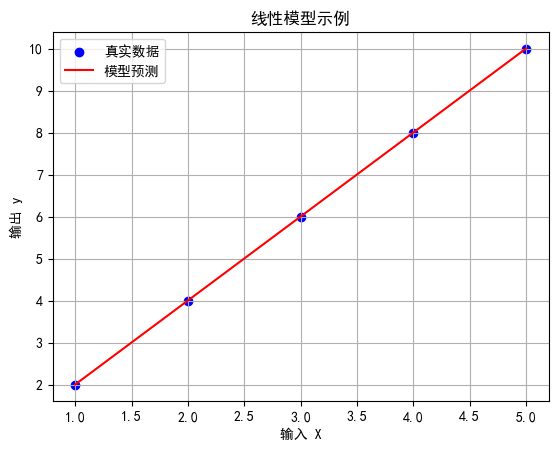

模型参数：w = 2, b = 0
预测结果：[ 2  4  6  8 10]


In [8]:
# 简单的线性模型实例
import numpy as np
import matplotlib.pyplot as plt

# 模拟数据
X = np.array([1 , 2 , 3 , 4 , 5])
y = np.array([2 , 4 , 6 , 8 , 10])

# 线性模型 : y = w * x + b
# 学习到的参数 : w = 2 , b = 0
w , b = 2 , 0

def linear_model(x):
    """线性模型函数"""
    return w * x + b

# 预测
predictions = linear_model(X)

# 设置中文字体
plt.rcParams['font.sans-serif'] = [
    # windows
    'SimHei', 'Microsoft YaHei'
]

# 修复负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False



# 可视化
plt.scatter(X , y , color = "blue" , label = "真实数据")
plt.plot(X , predictions , color = "red" , label = "模型预测")
plt.xlabel('输入 X')
plt.ylabel('输出 y')
plt.title('线性模型示例')
plt.legend()
plt.grid(True)
plt.show()
print(f"模型参数：w = {w}, b = {b}")
print(f"预测结果：{predictions}")

### 模型的复杂度

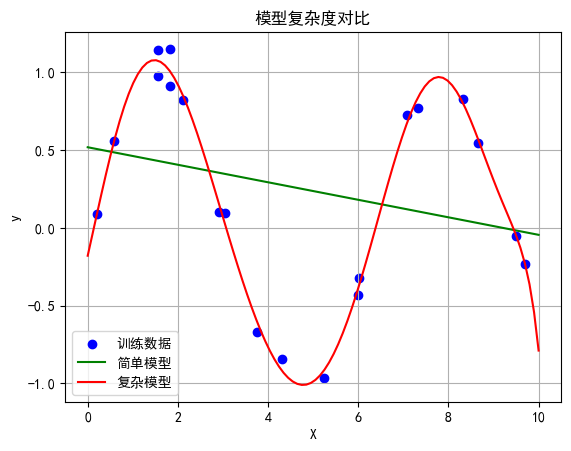

In [9]:
# 模型的复杂度对比
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

# 生成非线性数据
np.random.seed(42)
X = np.random.rand(20 , 1) * 10
y = np.sin(X) + np.random.randn(20 , 1) * 0.1

# 简单模型(线性)
simple_model = LinearRegression()
simple_model.fit(X , y)

# 复杂模型(高次多项式)
poly_features = PolynomialFeatures(degree=10)
X_poly = poly_features.fit_transform(X)
complex_model = LinearRegression()
complex_model.fit(X_poly, y)

# 可视化
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
X_test_poly = poly_features.transform(X_test)
plt.scatter(X, y, color='blue', label='训练数据')
plt.plot(X_test, simple_model.predict(X_test), color='green', label='简单模型')
plt.plot(X_test, complex_model.predict(X_test_poly), color='red', label='复杂模型')
plt.xlabel('X')
plt.ylabel('y')
plt.title('模型复杂度对比')
plt.legend()
plt.grid(True)
plt.show()

----

## 训练(Training)
训练是模型学习的过程，就像学生上课学习知识一样。在训练过程中，模型不断调整参数，使预测结果越来越接近真实标签。
![alt text](aade1323-0ab3-42224-8866-5af2a9dbe6a1.png)

100%|██████████| 100/100 [00:00<00:00, 49748.59it/s]

Epoch0 : Loss =  311.0148 , w = 1.8543 , b = 0.3074
Epoch10 : Loss =  4.0227 , w = 3.2077 , b = 0.6194
Epoch20 : Loss =  3.9440 , w = 3.1940 , b = 0.7066
Epoch30 : Loss =  3.8738 , w = 3.1808 , b = 0.7890
Epoch40 : Loss =  3.8111 , w = 3.1683 , b = 0.8668
Epoch50 : Loss =  3.7552 , w = 3.1565 , b = 0.9403
Epoch60 : Loss =  3.7054 , w = 3.1453 , b = 1.0097
Epoch70 : Loss =  3.6609 , w = 3.1348 , b = 1.0753
Epoch80 : Loss =  3.6212 , w = 3.1248 , b = 1.1373
Epoch90 : Loss =  3.5857 , w = 3.1155 , b = 1.1958


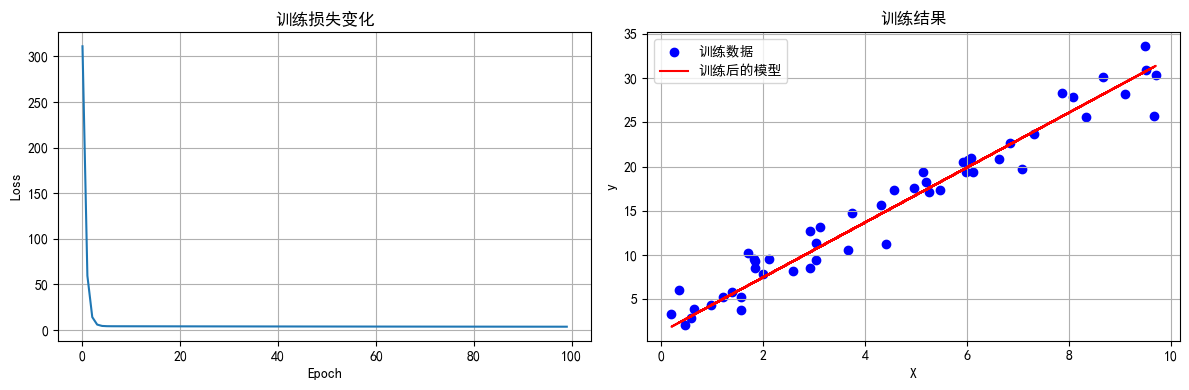

最终模型参数：w = 3.1074, b = 1.2457


In [10]:
#  训练过程实例 : 简单线性回归
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 生成训练数据  rand()是均匀分布    randn()是标准正态分布
np.random.seed(42)
X = np.random.rand(50 , 1) * 10
y = 3 * X + 2 + np.random.randn(50 , 1) * 2

# 初始化模型参数
w , b = 0 , 0
learing_rate = 0.01
epochs = 100

# 记录训练过程
loss_history = []

# 训练循环
for epoch in tqdm(range(epochs)):
    # 前向传播
    y_pred = w * X + b
    # 计算损失(均方误差)
    loss = np.mean((y_pred - y) ** 2)
    loss_history.append(loss)
    # 计算梯度      带入公式分别对 w 和 b 求导 
    dw = np.mean(2 * X * (y_pred - y))
    db = np.mean(2 * (y_pred - y))
    # 更新参数
    w -= learing_rate * dw
    b -= learing_rate * db
    if epoch % 10 == 0:
        print(f"Epoch{epoch} : Loss = {loss : .4f} , w = {w:.4f} , b = {b:.4f}")

# 可视化训练过程
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练损失变化')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.scatter(X, y, color='blue', label='训练数据')
plt.plot(X, w * X + b, color='red', label='训练后的模型')
plt.xlabel('X')
plt.ylabel('y')
plt.title('训练结果')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"最终模型参数：w = {w:.4f}, b = {b:.4f}")

---

## 推理(Inference)
推理是使用训练好的模型进行预测的过程，就像学生用学到的知识解答考试题一样。

In [11]:
# 推理过程实例
import numpy as np

# 假设我们已经训练好了一个房价预测模型
class HousePriceModel:
    def __init__(self):
        # 模拟训练好的参数
        self.feature_weights = {
            '面积' : 2.5 , 
            '卧室数' : 10.0,
            '房龄' : -1.0,
            '地段评分' : 50.0
        }
        self.bias = 50.0

    def predict(self , features):
        """
        使用训练好的模型进行房价预测
        """
        price = self.bias
        for feature_name, feature_value in features.items():
            if feature_name in self.feature_weights:
                price += self.feature_weights[feature_name] * feature_value
        return price

# 创建训练好的模型
model = HousePriceModel()

# 推理 : 预测新房价
new_houses = [
    {'面积': 80, '卧室数': 2, '房龄': 5, '地段评分': 8},
    {'面积': 120, '卧室数': 3, '房龄': 2, '地段评分': 9},
    {'面积': 60, '卧室数': 1, '房龄': 10, '地段评分': 6}
]

print("房价预测结果：")
for i, house in enumerate(new_houses, 1):
    predicted_price = model.predict(house)
    print(f"房子{i}：预测价格 {predicted_price:.2f} 万元")
# 批量推理
def batch_predict(model, house_list):
    """批量预测"""
    return [model.predict(house) for house in house_list]
batch_prices = batch_predict(model, new_houses)
print(f"\n批量预测结果：{batch_prices}")

房价预测结果：
房子1：预测价格 665.00 万元
房子2：预测价格 828.00 万元
房子3：预测价格 500.00 万元

批量预测结果：[665.0, 828.0, 500.0]


----

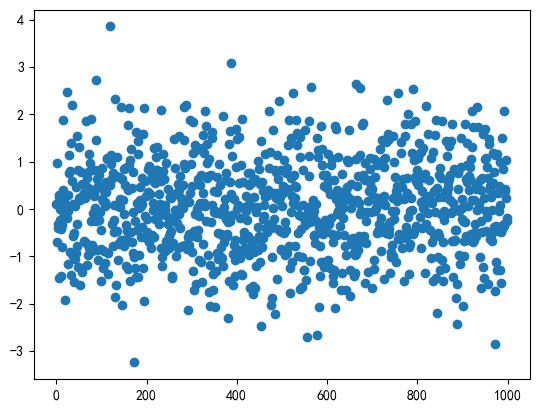

In [12]:
X = np.random.randn(1000 , 1)

plt.scatter(np.arange(len(X)) , X)

----

数据实例
         面积  卧室数  房龄  地段评分        价格
0  114.901425       2    10         9  461.720681
1   95.852071       3    13         5  389.942649
2  119.430656       2     4         6  424.874510
3  145.690896       3     5         4  444.869531
4   92.975399       3     9         6  337.829874

训练集大小：1600
测试集大小：400

模型训练完成！多项式阶数: 3
截距: 39.81
特征数量（含交叉项）: 35

模型评估：
训练集 MSE: 2685.67, R²: 0.75
测试集 MSE: 2652.14, R²: 0.75

新房价预测：
房子1: 352.16 万元
房子2: 501.99 万元
房子3: 232.10 万元


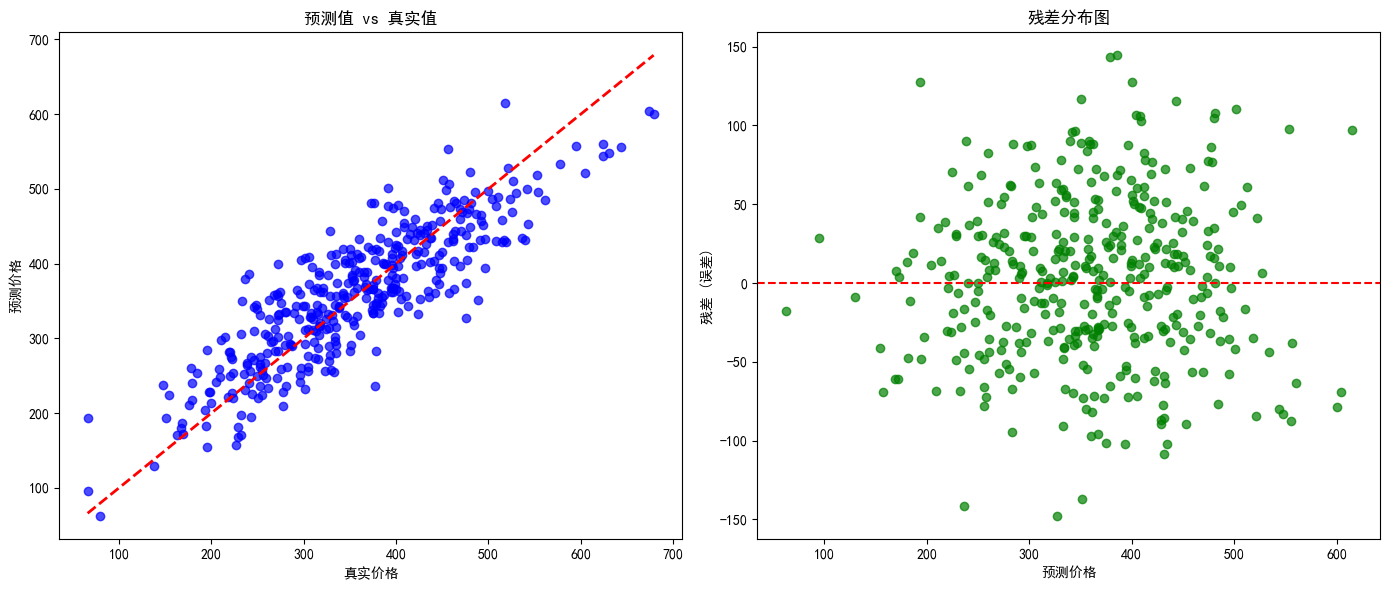

In [31]:
# 完整示例
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 解决中文对齐问题
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.unicode.east_asian_width', True)

# 1. 数据准备
np.random.seed(42)
n_samples = 2000
# 生成特征数据
area = np.random.normal(100 , 30 , n_samples)   # 面积      正态分布 normal(均值 , 标准差 , 个数)
bedrooms = np.random.randint(1, 5, n_samples)  # 卧室数
age = np.random.randint(0, 20, n_samples)  # 房龄
location_score = np.random.randint(1, 10, n_samples)  # 地段评分
# 生成标签（房价）- 基于特征的线性组合加噪声
price = (area * 2.5 + bedrooms * 20 + age * -2 + location_score * 15 +
         np.random.normal(0, 50, n_samples))
# 创建数据框
data = pd.DataFrame({
    '面积': area,
    '卧室数': bedrooms,
    '房龄': age,
    '地段评分': location_score,
    '价格': price
})
print("数据实例")
print(data.head())


# 2.划分数据集与测试集
features = ['面积' , '卧室数' , '房龄' , '地段评分']
X = data[features]
y = data["价格"]
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)     
# test_size：测试集占比。例如 0.2 表示 20% 为测试集，80% 为训练集。
# random_state：随机种子。设置一个固定值（如 42）能保证每次运行代码时，划分的结果完全一致
print(f"\n训练集大小：{X_train.shape[0]}")
print(f"测试集大小：{X_test.shape[0]}")


# 3. 训练模型
degree = 3 # 建议先从 2 开始，10 会让数值爆炸
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X_train, y_train)
# model = LinearRegression()
# model.fit(X_train, y_train)
# print(f"\n模型参数：")
# for feature, coef in zip(features, model.coef_):
#     print(f"{feature}: {coef:.2f}")
# print(f"截距: {model.intercept_:.2f}")
# 获取模型参数（因为嵌套在 pipeline 里，取出来稍微麻烦点）
lin_reg = model.named_steps['linearregression']
print(f"\n模型训练完成！多项式阶数: {degree}")
print(f"截距: {lin_reg.intercept_:.2f}")
print(f"特征数量（含交叉项）: {len(lin_reg.coef_)}")



# 4. 评估模型
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\n模型评估：")
print(f"训练集 MSE: {train_mse:.2f}, R²: {train_r2:.2f}")
print(f"测试集 MSE: {test_mse:.2f}, R²: {test_r2:.2f}")


# 5. 推理（预测新数据）
new_houses = pd.DataFrame({
    '面积': [85, 120, 65],
    '卧室数': [2, 3, 1],
    '房龄': [3, 1, 8],
    '地段评分': [7, 9, 5]
})
predictions = model.predict(new_houses)
print(f"\n新房价预测：")
for i, price in enumerate(predictions, 1):
    print(f"房子{i}: {price:.2f} 万元")



# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体（防止中文乱码，根据系统不同可能需要调整）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 创建一个画布，包含两个子图
plt.figure(figsize=(14, 6))

# 图 1：散点对比图 (预测值 vs 真实值)
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 画一条 45 度的参考线
plt.xlabel('真实价格')
plt.ylabel('预测价格')
plt.title('预测值 vs 真实值')

# 图 2：残差图 (你代码最后一行想表达的内容)
plt.subplot(1, 2, 2)
residuals = y_test_pred - y_test
plt.scatter(y_test_pred, residuals, alpha=0.7, color='g')
plt.axhline(y=0, color='r', linestyle='--') # 画一条 y=0 的横线
plt.xlabel('预测价格')
plt.ylabel('残差 (误差)')
plt.title('残差分布图')

plt.tight_layout()
plt.show()